In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Pfadangaben aktualisieren
main_path = '/Users/maxbreitruck/Downloads/max_msci_index'
excel_path = "/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/Paper #4/MSCI_Consumer.xlsx"
company_info_df = pd.read_excel(excel_path)

# Liste zur Speicherung der DataFrames aus jedem Subordner
df_list = []

# Zähler für die Unternehmen
company_no = 1

# Durchlaufen jedes Subordners
for subfolder in sorted(os.listdir(main_path)):
    subfolder_path = os.path.join(main_path, subfolder)
    if os.path.isdir(subfolder_path):
        all_files = [os.path.join(subfolder_path, f) for f in os.listdir(subfolder_path) if f.endswith('.csv')]
        
        for file in all_files:
            practice_df = pd.read_csv(file)
            practice_df['date'] = pd.to_datetime(practice_df['date'])
            practice_df['practice'] = os.path.basename(file).split('.')[0]
            practice_df['subfolder_name'] = subfolder
            # Füge die Unternehmensnummer zum DataFrame hinzu
            practice_df['Company No'] = company_no
            df_list.append(practice_df)
        
        # Zähler nach der Verarbeitung jedes Subfolders inkrementieren
        company_no += 1

# Zusammenführen aller DataFrames
df = pd.concat(df_list)
df.sort_values(by=['practice', 'date'], inplace=True)

# Verknüpfung mit company_info_df, um Unternehmensnamen und Supersektor hinzuzufügen
df = df.merge(company_info_df, left_on='subfolder_name', right_on='Subfolder Name', how='left')


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545072 entries, 0 to 4545071
Data columns (total 14 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Unnamed: 0         float64       
 1   date               datetime64[ns]
 2   pos                float64       
 3   neu                float64       
 4   neg                float64       
 5   nf                 float64       
 6   sentiment          float64       
 7   volume             int64         
 8   practice           object        
 9   subfolder_name     object        
 10  Company No         int64         
 11  Subfolder Name     object        
 12  Supersector        object        
 13  Company Name Full  object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(5)
memory usage: 485.5+ MB


In [4]:
import os
import pandas as pd

# Pfad zum Ordner mit den Volumendaten
volume_path = '/Users/maxbreitruck/Downloads/max_msci_index/volumes'

# Liste für die gesammelten Daten
data_list = []

# Initialisiere den Unternehmenszähler
company_no = 1

# Durchlaufe alle Dateien im angegebenen Verzeichnis
for file_name in sorted(os.listdir(volume_path)):
    if file_name.endswith('.csv'):
        # Extrahiere den Unternehmensnamen aus dem Dateinamen (ohne ".csv")
        company_name = file_name[:-4]
        
        # Vollständiger Pfad zur CSV-Datei
        file_path = os.path.join(volume_path, file_name)
        
        # Lade die CSV-Datei
        df_2 = pd.read_csv(file_path)
        
        # Umwandeln der 'date'-Spalte in ein Datumsformat
        df_2['date'] = pd.to_datetime(df_2['date'])
        
        # Aggregiere die Volumendaten auf Monatsbasis
        df_2['year_month'] = df_2['date'].dt.to_period('M')  # Nur das Jahr und den Monat extrahieren
        
        # Summiere das Volumen pro Firma und Monat
        monthly_volume_df = df_2.groupby('year_month').agg({'volume': 'sum'}).reset_index()
        
        # Konvertiere year_month zurück in ein vollständiges Datum (Monatsletzter)
        monthly_volume_df['date'] = monthly_volume_df['year_month'].dt.to_timestamp(how='end').dt.strftime('%Y-%m-%d')
        
        # Füge die Firmeninformationen hinzu
        monthly_volume_df['company'] = company_name
        monthly_volume_df['Company No'] = company_no
        
        # Entferne die year_month-Spalte, falls nicht benötigt
        monthly_volume_df.drop(columns=['year_month'], inplace=True)

        # Füge den DataFrame zur Liste hinzu
        data_list.append(monthly_volume_df)
        
        # Inkrementiere den Unternehmenszähler
        company_no += 1

# Kombiniere alle DataFrames in der Liste zu einem einzigen DataFrame
combined_df = pd.concat(data_list).reset_index(drop=True)

# Sortiere nach Unternehmen und Datum
combined_df.sort_values(by=['company', 'date'], inplace=True)

# Ergebnis anzeigen
print(combined_df.head(20))

# Optional: Speichern als CSV
# combined_df.to_csv("combined_corrected.csv", index=False)

    volume        date         company  Company No
0     1228  2023-01-31  ahold_delhaize           1
1     1987  2023-02-28  ahold_delhaize           1
2     1371  2023-03-31  ahold_delhaize           1
3     1432  2023-04-30  ahold_delhaize           1
4     1798  2023-05-31  ahold_delhaize           1
5     1561  2023-06-30  ahold_delhaize           1
6     1319  2023-07-31  ahold_delhaize           1
7     2456  2023-08-31  ahold_delhaize           1
8     1978  2023-09-30  ahold_delhaize           1
9     2043  2023-10-31  ahold_delhaize           1
10    2760  2023-11-30  ahold_delhaize           1
11     973  2023-12-31  ahold_delhaize           1
12    1345  2024-01-31  ahold_delhaize           1
13    2951  2024-02-29  ahold_delhaize           1
14    1065  2024-03-31  ahold_delhaize           1
15    1355  2024-04-30  ahold_delhaize           1
16    2046  2024-05-31  ahold_delhaize           1
17    1272  2024-06-30  ahold_delhaize           1
18    1480  2024-07-31  ahold_d

In [5]:
combined_df.head()

,volume,date,company,Company No
0,1228,2023-01-31,ahold_delhaize,1
1,1987,2023-02-28,ahold_delhaize,1
2,1371,2023-03-31,ahold_delhaize,1
3,1432,2023-04-30,ahold_delhaize,1
4,1798,2023-05-31,ahold_delhaize,1


In [6]:
# Dein bestehender DataFrame
# Stelle sicher, dass 'combined_df' bereits existiert und eine 'date' Spalte hat
combined_df["date"] = pd.to_datetime(combined_df["date"])

# Erstelle die year_month Spalte
combined_df["year_month"] = combined_df["date"].dt.to_period("M")

# Berechne das maximale Volumen pro Monat und die dazugehörige Firma
max_volume_per_month = combined_df.loc[combined_df.groupby("year_month")["volume"].idxmax(), ["year_month", "volume", "company"]]

# Umbenennen der Spalten für Klarheit
max_volume_per_month.rename(columns={"volume": "max_volume_per_month", "company": "max_volume_company"}, inplace=True)

# Mergen mit dem ursprünglichen DataFrame
combined_df = combined_df.merge(max_volume_per_month, on="year_month", how="left")

# Ergebnis anzeigen
print(combined_df.head())

   volume       date         company  Company No year_month  \
0    1228 2023-01-31  ahold_delhaize           1    2023-01   
1    1987 2023-02-28  ahold_delhaize           1    2023-02   
2    1371 2023-03-31  ahold_delhaize           1    2023-03   
3    1432 2023-04-30  ahold_delhaize           1    2023-04   
4    1798 2023-05-31  ahold_delhaize           1    2023-05   

   max_volume_per_month max_volume_company  
0                 10286             nestle  
1                 14263             nestle  
2                 13862             nestle  
3                 18886     anheuser_busch  
4                 16484     anheuser_busch  


In [7]:
combined_df.rename(columns={"max_volume_per_month": "max_volume"}, inplace=True)

In [8]:
# Berechnung der 'weight' Spalte mit logarithmischer Transformation
combined_df['log_weight'] = np.log(combined_df['max_volume']) - np.log(combined_df['volume'])

# Behandle Division durch Null oder Fälle, wo das Volumen 0 ist, um Unendlichkeiten oder NaNs zu vermeiden
combined_df['log_weight'].replace([float('inf'), float('-inf')], np.nan, inplace=True)

combined_df


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_49168/971512047.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['log_weight'].replace([float('inf'), float('-inf')], np.nan, inplace=True)


,volume,date,company,Company No,year_month,max_volume,max_volume_company,log_weight
0,1228,2023-01-31,ahold_delhaize,1,2023-01,10286,nestle,2.125397
1,1987,2023-02-28,ahold_delhaize,1,2023-02,14263,nestle,1.971043
2,1371,2023-03-31,ahold_delhaize,1,2023-03,13862,nestle,2.313611
3,1432,2023-04-30,ahold_delhaize,1,2023-04,18886,anheuser_busch,2.579349
4,1798,2023-05-31,ahold_delhaize,1,2023-05,16484,anheuser_busch,2.215715
...,...,...,...,...,...,...,...,...
895,3701,2024-09-30,unilever,36,2024-09,11493,nestle,1.133135
896,3917,2024-10-31,unilever,36,2024-10,20233,nestle,1.641989
897,2613,2024-11-30,unilever,36,2024-11,14380,nestle,1.705339
898,2285,2024-12-31,unilever,36,2024-12,12295,nestle,1.682827


In [9]:
# Function to extract 'capability' from the 'practice' column
def extract_capability(practice):
    parts = practice.split('-')
    if len(parts) > 2:
        return parts[1][:3]  # Extract the first 2-3 letters of the second part
    else:
        return 'Unknown'

# Function to extract 'pillar' from the 'practice' column
def extract_pillar(practice):
    parts = practice.split('-')
    return parts[0][:3]  # Extract the first 2-3 letters of the first part

# Apply these functions to create the new columns
df['capability'] = df['practice'].apply(extract_capability)
df['pillar'] = df['practice'].apply(extract_pillar)

df.head()

,Unnamed: 0,date,pos,neu,neg,nf,sentiment,volume,practice,subfolder_name,Company No,Subfolder Name,Supersector,Company Name Full,capability,pillar
0,0.0,2023-01-01,0.0,0.0,0.0,0.0,0.5,0,BMI-CCF-Capability Focus,ahold_delhaize_AD_NL0011794037,1,ahold_delhaize_AD_NL0011794037,Consumer Goods,Ahold,CCF,BMI
1,0.0,2023-01-01,0.0,0.0,0.0,0.0,0.5,0,BMI-CCF-Capability Focus,anheuser_busch_ABI_BE0974293251,2,anheuser_busch_ABI_BE0974293251,Consumer Goods,Anheuser Busch,CCF,BMI
2,0.0,2023-01-01,0.0,0.0,0.0,0.0,0.5,0,BMI-CCF-Capability Focus,associated_british_foods_ABF_GB0006731235,3,associated_british_foods_ABF_GB0006731235,Consumer Goods,Associated Britisch Foods,CCF,BMI
3,0.0,2023-01-01,0.0,0.0,0.0,0.0,0.5,0,BMI-CCF-Capability Focus,barry_callebaut_BARN_CH0009002962,4,barry_callebaut_BARN_CH0009002962,Consumer Goods,Barry Calebaut,CCF,BMI
4,0.0,2023-01-01,0.0,0.0,0.0,0.0,0.5,0,BMI-CCF-Capability Focus,beiersdorf_BEI_DE0005200000,5,beiersdorf_BEI_DE0005200000,Consumer Goods,Beiersdorf,CCF,BMI


In [10]:
# Datentypen optimieren, z.B. für 'Company No'
df['Company No'] = df['Company No'].astype('category')
combined_df['Company No'] = combined_df['Company No'].astype('int32') # Angenommen, dies ist der geeignete Typ

# Datum nur einmal umwandeln und Jahr-Monat extrahieren
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')

combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df['year_month'] = combined_df['date'].dt.to_period('M')

# Spalten vor dem Merge filtern, um den Speicherverbrauch zu reduzieren
df_filtered = df[['Company No', 'year_month', 'Company Name Full', 'date', 'volume',	'practice',	'subfolder_name',	'Subfolder Name',	'Supersector',	'capability',	'pillar', "sentiment"]] # und andere notwendige Spalten
combined_df_filtered = combined_df[['Company No', 'year_month', 'log_weight']]

# Merge durchführen
df_merged_volume = pd.merge(df_filtered, combined_df_filtered, on=['Company No', 'year_month'], how='left')

# Ergebnis überprüfen
df_merged_volume.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545072 entries, 0 to 4545071
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Company No         int64         
 1   year_month         period[M]     
 2   Company Name Full  object        
 3   date               datetime64[ns]
 4   volume             int64         
 5   practice           object        
 6   subfolder_name     object        
 7   Subfolder Name     object        
 8   Supersector        object        
 9   capability         object        
 10  pillar             object        
 11  sentiment          float64       
 12  log_weight         float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(7), period[M](1)
memory usage: 450.8+ MB


In [11]:
df_merged_volume.head(1185)
df = df_merged_volume

In [12]:
# Replace 'PA0' with 'PAO' in the 'pillar' column
df['pillar'] = df['pillar'].replace('PA0', 'PAO')

# Verify the replacement
print(df['pillar'].unique())


['BMI' 'CE' 'CSE' 'CSG' 'DA' 'DLC' 'DST' 'PAO' 'TI' 'aho' 'anh' 'ass'
 'bar' 'bei' 'bri' 'car' 'coc' 'dan' 'dav' 'dia' 'ess' 'hal' 'hei' 'hen'
 'imp' 'j_s' 'jde' 'jer' 'ker' 'kes' 'l_o' 'lin' 'lot' 'mar' 'nes' 'ork'
 'per' 'rec' 'sal' 'tes' 'uni']


In [14]:
df.head(150)

,Company No,year_month,Company Name Full,date,volume,practice,subfolder_name,Subfolder Name,Supersector,capability,pillar,sentiment,log_weight
0,1,2023-01,Ahold,2023-01-01,0,BMI-CCF-Capability Focus,ahold_delhaize_AD_NL0011794037,ahold_delhaize_AD_NL0011794037,Consumer Goods,CCF,BMI,0.5,2.125397
1,2,2023-01,Anheuser Busch,2023-01-01,0,BMI-CCF-Capability Focus,anheuser_busch_ABI_BE0974293251,anheuser_busch_ABI_BE0974293251,Consumer Goods,CCF,BMI,0.5,0.787699
2,3,2023-01,Associated Britisch Foods,2023-01-01,0,BMI-CCF-Capability Focus,associated_british_foods_ABF_GB0006731235,associated_british_foods_ABF_GB0006731235,Consumer Goods,CCF,BMI,0.5,1.319183
3,4,2023-01,Barry Calebaut,2023-01-01,0,BMI-CCF-Capability Focus,barry_callebaut_BARN_CH0009002962,barry_callebaut_BARN_CH0009002962,Consumer Goods,CCF,BMI,0.5,3.625411
4,5,2023-01,Beiersdorf,2023-01-01,0,BMI-CCF-Capability Focus,beiersdorf_BEI_DE0005200000,beiersdorf_BEI_DE0005200000,Consumer Goods,CCF,BMI,0.5,1.349830
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,2,2023-01,Anheuser Busch,2023-01-05,0,BMI-CCF-Capability Focus,anheuser_busch_ABI_BE0974293251,anheuser_busch_ABI_BE0974293251,Consumer Goods,CCF,BMI,0.5,0.787699
146,3,2023-01,Associated Britisch Foods,2023-01-05,0,BMI-CCF-Capability Focus,associated_british_foods_ABF_GB0006731235,associated_british_foods_ABF_GB0006731235,Consumer Goods,CCF,BMI,0.5,1.319183
147,4,2023-01,Barry Calebaut,2023-01-05,0,BMI-CCF-Capability Focus,barry_callebaut_BARN_CH0009002962,barry_callebaut_BARN_CH0009002962,Consumer Goods,CCF,BMI,0.5,3.625411
148,5,2023-01,Beiersdorf,2023-01-05,0,BMI-CCF-Capability Focus,beiersdorf_BEI_DE0005200000,beiersdorf_BEI_DE0005200000,Consumer Goods,CCF,BMI,0.5,1.349830


In [15]:
#df["volume_weighted"] = df["volume"] * df["log_weight"]
df["volume_weighted"] = df["volume"] * df["log_weight"] * (1 + (df["sentiment"] - 0.5) * 0.2)

In [16]:
df.head(25)

,Company No,year_month,Company Name Full,date,volume,practice,subfolder_name,Subfolder Name,Supersector,capability,pillar,sentiment,log_weight,volume_weighted
0,1,2023-01,Ahold,2023-01-01,0,BMI-CCF-Capability Focus,ahold_delhaize_AD_NL0011794037,ahold_delhaize_AD_NL0011794037,Consumer Goods,CCF,BMI,0.5,2.125397,0.0
1,2,2023-01,Anheuser Busch,2023-01-01,0,BMI-CCF-Capability Focus,anheuser_busch_ABI_BE0974293251,anheuser_busch_ABI_BE0974293251,Consumer Goods,CCF,BMI,0.5,0.787699,0.0
2,3,2023-01,Associated Britisch Foods,2023-01-01,0,BMI-CCF-Capability Focus,associated_british_foods_ABF_GB0006731235,associated_british_foods_ABF_GB0006731235,Consumer Goods,CCF,BMI,0.5,1.319183,0.0
3,4,2023-01,Barry Calebaut,2023-01-01,0,BMI-CCF-Capability Focus,barry_callebaut_BARN_CH0009002962,barry_callebaut_BARN_CH0009002962,Consumer Goods,CCF,BMI,0.5,3.625411,0.0
4,5,2023-01,Beiersdorf,2023-01-01,0,BMI-CCF-Capability Focus,beiersdorf_BEI_DE0005200000,beiersdorf_BEI_DE0005200000,Consumer Goods,CCF,BMI,0.5,1.349830,0.0
5,6,2023-01,Biritsch American Tobacco,2023-01-01,0,BMI-CCF-Capability Focus,british_american_tobacco_BATS_GB0002875804,british_american_tobacco_BATS_GB0002875804,Consumer Goods,CCF,BMI,0.5,1.356979,0.0
6,7,2023-01,Carlsberg,2023-01-01,0,BMI-CCF-Capability Focus,carlsberg_CARL B_DK0010181759,carlsberg_CARL B_DK0010181759,Consumer Goods,CCF,BMI,0.5,2.223725,0.0
7,8,2023-01,Carrefour,2023-01-01,0,BMI-CCF-Capability Focus,carrefour_CA_FR0000120172,carrefour_CA_FR0000120172,Consumer Goods,CCF,BMI,0.5,1.307254,0.0
8,9,2023-01,Coca Cola European Partners,2023-01-01,0,BMI-CCF-Capability Focus,coca_cola_european_partners_CCEP_GB00BDCPN049,coca_cola_european_partners_CCEP_GB00BDCPN049,Consumer Goods,CCF,BMI,0.5,3.415493,0.0
9,10,2023-01,Coca Cola,2023-01-01,0,BMI-CCF-Capability Focus,coca_cola_hbc_CCH_CH0198251305,coca_cola_hbc_CCH_CH0198251305,Consumer Goods,CCF,BMI,0.5,3.403728,0.0


In [17]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Beispiel: Vorhandener DataFrame 'df' mit mind. folgenden Spalten:
# 'date', 'practice', 'Company Name Full', 'Supersector', 'capability',
# 'pillar', 'volume_weighted'
# ------------------------------------------------------------------

# 1) Datum parsen und Monatsspalte erzeugen
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.to_period('M')  # Monats-Periode

# 2) Tägliche Aggregation pro Firma/Praxis usw.
#    (falls du bereits reine Einträge pro Tag hast, fällt dieser Schritt geringer aus)
daily_data = (
    df
    .groupby(['practice', 'Company Name Full', 'Supersector', 'capability', 'pillar', 'date'])
    ['volume_weighted']
    .sum()  # z.B. Summierung pro Tag
    .reset_index(name='daily_volume')
)

# Damit wir später die Perzentile joinen können, holen wir uns ebenfalls den 'month' in daily_data
daily_data['month'] = daily_data['date'].dt.to_period('M')

# 3) Monats-Perzentile pro Praxis + Supersector berechnen
def calculate_percentiles(group):
    # group['daily_volume'] enthält hier alle Tagesvolumina für Praxis/Supersector im jeweiligen Monat
    # np.percentile -> liefert uns in der Reihenfolge p10, p20, ..., p100
    percentiles = np.percentile(group['daily_volume'], [10 * i for i in range(1, 11)])
    # Als Series zurückgeben mit sinnvollen Spaltennamen
    return pd.Series(percentiles, index=[f'p{10 * i}' for i in range(1, 11)])

monthly_percentiles = (
    daily_data
    .groupby(['practice', 'Supersector', 'month'])
    .apply(calculate_percentiles)
    .reset_index()
)

# 4) Merge (Join) der Monats-Perzentile auf den täglichen Datensatz
#    => Jetzt hat jede Tageszeile ihre passenden p10, p20, …, p100 anhand von (practice, Supersector, month)
daily_merged_df = pd.merge(
    daily_data,
    monthly_percentiles,
    on=['practice', 'Supersector', 'month'],
    how='left'
)

# 5) Score-Funktion definieren und anwenden
def assign_score(volume, row_dict):
    """
    volume: der daily_volume
    row_dict: Dictionary der Zeile, enthält p10,...,p100
    """
    if volume == 0:
        return 0
    # Von oben nach unten durchgehen: wenn volume > p100, Score=10; > p90, Score=9; usw.
    for i in range(10, 0, -1):
        if volume > row_dict.get(f'p{i*10}', np.inf):
            return i
    return 1  # Falls nichts zutrifft, minimaler Score

# Wir gehen jede Zeile durch, lesen daily_volume und die pX-Werte heraus
daily_merged_df['score'] = daily_merged_df.apply(
    lambda row: assign_score(row['daily_volume'], row.to_dict()),
    axis=1
)

# Optional: Sortieren nach Datum & ggf. Ausgabe
daily_merged_df.sort_values(['practice', 'Company Name Full', 'date'], inplace=True)
daily_merged_df.reset_index(drop=True, inplace=True)

# ----------------------
# Ergebnis:
# daily_merged_df hat jetzt:
# practice | Company Name Full | Supersector | capability | pillar | date | daily_volume |
# month    | p10 ... p100      | score
# ----------------------

# Beispielhafte Ausgabe
print(daily_merged_df.head(20))

/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_49168/128316356.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_percentiles)


                    practice Company Name Full     Supersector capability  \
0   BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
1   BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
2   BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
3   BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
4   BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
5   BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
6   BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
7   BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
8   BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
9   BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
10  BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   
11  BMI-CCF-Capability Focus             Ahold  Consumer Goods        CCF   

In [18]:
daily_merged_df.head(56000)

,practice,Company Name Full,Supersector,capability,pillar,date,daily_volume,month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
0,BMI-CCF-Capability Focus,Ahold,Consumer Goods,CCF,BMI,2023-01-01,0.0,2023-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
1,BMI-CCF-Capability Focus,Ahold,Consumer Goods,CCF,BMI,2023-01-02,0.0,2023-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
2,BMI-CCF-Capability Focus,Ahold,Consumer Goods,CCF,BMI,2023-01-03,0.0,2023-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
3,BMI-CCF-Capability Focus,Ahold,Consumer Goods,CCF,BMI,2023-01-04,0.0,2023-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
4,BMI-CCF-Capability Focus,Ahold,Consumer Goods,CCF,BMI,2023-01-05,0.0,2023-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55995,BMI-CCF-Focus Strategy,Associated Britisch Foods,Consumer Goods,CCF,BMI,2023-02-21,0.0,2023-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,151.265177,0
55996,BMI-CCF-Focus Strategy,Associated Britisch Foods,Consumer Goods,CCF,BMI,2023-02-22,0.0,2023-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,151.265177,0
55997,BMI-CCF-Focus Strategy,Associated Britisch Foods,Consumer Goods,CCF,BMI,2023-02-23,0.0,2023-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,151.265177,0
55998,BMI-CCF-Focus Strategy,Associated Britisch Foods,Consumer Goods,CCF,BMI,2023-02-24,0.0,2023-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,151.265177,0


### hier neu pro Tag

In [19]:
import pandas as pd

# ---------------------------------------------------------
# Angenommen, du hast bereits daily_merged_df wie folgt:
#    practice | Company Name Full | Supersector | capability | pillar | date
#    daily_volume | month | p10 ... p100 | score
# ---------------------------------------------------------

# 1a) Maximal mögliche Punktzahl pro Capability 
#     (abhängig von der Anzahl 'practice' je capability × max. Score 10)
max_scores_per_capability = daily_merged_df.groupby('capability')['practice'].nunique().reset_index()
max_scores_per_capability['max_score_per_capability'] = max_scores_per_capability['practice'] * 10

# 1b) Tägliche Summe der Score-Werte je (Firma × Capability × Supersector × pillar × date).
capability_scores = (
    daily_merged_df
    .groupby(['Company Name Full', 'capability', 'Supersector', 'pillar', 'date'])['score']
    .sum()
    .reset_index()
)

# 1c) Umbenennen für Klarheit
capability_scores.rename(columns={'score': 'maturity_score'}, inplace=True)

# 1d) Merge mit den max. möglichen Capability-Scores
final_scores = pd.merge(
    capability_scores,
    max_scores_per_capability[['capability', 'max_score_per_capability']],
    on='capability',
    how='left'
)

# 1e) Nur die relevanten Spalten
final_scores = final_scores[
    ['Company Name Full', 'capability', 'Supersector', 'pillar', 'date',
     'maturity_score', 'max_score_per_capability']
]

print(">>> Capability-Ebene pro Tag:")
print(final_scores.head())

>>> Capability-Ebene pro Tag:
  Company Name Full capability     Supersector pillar       date  \
0             Ahold        AID  Consumer Goods     TI 2023-01-01   
1             Ahold        AID  Consumer Goods     TI 2023-01-02   
2             Ahold        AID  Consumer Goods     TI 2023-01-03   
3             Ahold        AID  Consumer Goods     TI 2023-01-04   
4             Ahold        AID  Consumer Goods     TI 2023-01-05   

   maturity_score  max_score_per_capability  
0               0                        60  
1               0                        60  
2               0                        60  
3               0                        60  
4               0                        60  


In [20]:
# 2a) Sortieren nach (Firma, Capability, Datum)
final_scores_sorted = final_scores.sort_values(
    by=['Company Name Full', 'capability', 'date']
)

# 2b) Kumulative Maximum-Funktion je (Firma, Capability)
final_scores_sorted['adjusted_maturity_score'] = (
    final_scores_sorted
    .groupby(['Company Name Full', 'capability'])['maturity_score']
    .cummax()
)

# Für den nächsten Schritt kopieren wir uns nur die Spalten, die wir brauchen
final_scores_with_supersector = final_scores_sorted[
    ['Company Name Full', 'pillar', 'Supersector', 'date',
     'adjusted_maturity_score', 'max_score_per_capability']
]

In [21]:
# 3a) Summiere pro Tag über alle Capabilities einer Säule (pro Firma, Pillar, ...)
pillar_scores = (
    final_scores_with_supersector
    .groupby(['Company Name Full', 'pillar', 'Supersector', 'date'])
    .agg({
        'adjusted_maturity_score': 'sum',
        'max_score_per_capability': 'sum'
    })
    .reset_index()
)

# 3b) Berechne einen Pillar-Score als Anteil an den maximal möglichen Punkten
pillar_scores['pillar_score'] = (
    pillar_scores['adjusted_maturity_score'] /
    pillar_scores['max_score_per_capability']
)

# 3c) Relevante Spalten
final_pillar_scores = pillar_scores[
    ['Company Name Full', 'pillar', 'Supersector', 'date', 'pillar_score']
]

print(">>> Pillar-Ebene pro Tag:")
print(final_pillar_scores.head())

>>> Pillar-Ebene pro Tag:
  Company Name Full pillar     Supersector       date  pillar_score
0             Ahold    BMI  Consumer Goods 2023-01-01      0.000000
1             Ahold    BMI  Consumer Goods 2023-01-02      0.000000
2             Ahold    BMI  Consumer Goods 2023-01-03      0.042857
3             Ahold    BMI  Consumer Goods 2023-01-04      0.042857
4             Ahold    BMI  Consumer Goods 2023-01-05      0.042857


### export Functionality Pillar

In [35]:
# Erstellen einer Kopie des DataFrames mit nur den Einträgen, bei denen die Spalte 'Pillar' den Wert 'TI' hat
pillar_scores_BMI = final_pillar_scores[final_pillar_scores['pillar'] == 'BMI'].copy()
pillar_scores_CSG = final_pillar_scores[final_pillar_scores['pillar'] == 'CSG'].copy()
pillar_scores_DA = final_pillar_scores[final_pillar_scores['pillar'] == 'DA'].copy()
pillar_scores_DLC = final_pillar_scores[final_pillar_scores['pillar'] == 'DLC'].copy()
pillar_scores_DST = final_pillar_scores[final_pillar_scores['pillar'] == 'DST'].copy()
pillar_scores_PAO = final_pillar_scores[final_pillar_scores['pillar'] == 'PAO'].copy()
pillar_scores_TI = final_pillar_scores[final_pillar_scores['pillar'] == 'TI'].copy()
pillar_scores_CE = final_pillar_scores[final_pillar_scores['pillar'] == 'CE'].copy()
# Ausgabe des neuen DataFrames


In [36]:
# Umbenennen der Spalte 'pillar_score' in 'Overall Maturity Score'
pillar_scores_BMI = pillar_scores_BMI.rename(columns={'pillar_score': 'Overall Maturity Score'})
pillar_scores_CSG = pillar_scores_CSG.rename(columns={'pillar_score': 'Overall Maturity Score'})
pillar_scores_DA = pillar_scores_DA.rename(columns={'pillar_score': 'Overall Maturity Score'})
pillar_scores_DLC = pillar_scores_DLC.rename(columns={'pillar_score': 'Overall Maturity Score'})
pillar_scores_DST = pillar_scores_DST.rename(columns={'pillar_score': 'Overall Maturity Score'})
pillar_scores_PAO = pillar_scores_PAO.rename(columns={'pillar_score': 'Overall Maturity Score'})
pillar_scores_TI = pillar_scores_TI.rename(columns={'pillar_score': 'Overall Maturity Score'})
pillar_scores_CE = pillar_scores_CE.rename(columns={'pillar_score': 'Overall Maturity Score'})



In [37]:
pillar_scores_DLC.head()

,Company Name Full,pillar,Supersector,date,Overall Maturity Score
3780,Ahold,DLC,Consumer Goods,2023-01-01,0.008
3781,Ahold,DLC,Consumer Goods,2023-01-02,0.064
3782,Ahold,DLC,Consumer Goods,2023-01-03,0.124
3783,Ahold,DLC,Consumer Goods,2023-01-04,0.152
3784,Ahold,DLC,Consumer Goods,2023-01-05,0.152


In [38]:
pillar_scores_BMI.to_csv("pillar_scores_BMI_V2.csv", index=False)
pillar_scores_CSG.to_csv("pillar_scores_CSG_V2.csv", index=False)
pillar_scores_DA.to_csv("pillar_scores_DA_V2.csv", index=False)
pillar_scores_DLC.to_csv("pillar_scores_DLC_V2.csv", index=False)
pillar_scores_DST.to_csv("pillar_scores_DST_V2.csv", index=False)
pillar_scores_PAO.to_csv("pillar_scores_PAO_V2.csv", index=False)
pillar_scores_TI.to_csv("pillar_scores_TI_V2.csv", index=False)
pillar_scores_CE.to_csv("pillar_scores_CE_V2.csv", index=False)

In [22]:
# Beispiel-Gewichte für jede Säule:
pillar_weights = {
    'BMI': 0.4,  # Example: Business Model Innovation has full weight
    'CE': 1.68,   # Example: Customer Experience weighted at 90%
    #'CSE': 0.64,  # Example: Cybersecurity & Data Protection
    'CSG': 0.64,  # Example: Compliance & Sustainability
    'DA': 1.28,   # Example: Data Analytics gets higher weight
    'DLC': 1.68,  # Example: Digital Leadership Culture
    'DST': 0.64,  # Example: Digital Strategy & Transformation
    'PAO': 0.88,  # Example: Process Automation & Optimization
    'TI': 0.8
}

# 4a) Falls du wirklich pro Tag je Säule nur einen Eintrag hast,
#     kannst du direkt pivotieren:
pivot_table_daily = final_pillar_scores.pivot_table(
    index=['Company Name Full', 'date'],
    columns='pillar',
    values='pillar_score'
).reset_index()

# 4b) Fehlende Säulen-Scores => 0
pivot_table_daily_filled = pivot_table_daily.fillna(0)

# 4c) Gewichte anwenden
for p, w in pillar_weights.items():
    if p in pivot_table_daily_filled.columns:
        pivot_table_daily_filled[p] *= w

# 4d) Summiere alles und teile durch die Gesamtgewichtssumme
total_weight = sum(pillar_weights.values())

pivot_table_daily_filled['Overall Maturity Score'] = (
    pivot_table_daily_filled.iloc[:, 2:].sum(axis=1) / total_weight
)

# 4e) Endergebnis: pro (Firma, Tag) der gewogene Score
weighted_maturity_scores_daily = pivot_table_daily_filled[
    ['Company Name Full', 'date', 'Overall Maturity Score']
]

print(">>> Weighted Overall Score pro Tag:")
print(weighted_maturity_scores_daily.head())

>>> Weighted Overall Score pro Tag:
pillar Company Name Full       date  Overall Maturity Score
0                  Ahold 2023-01-01                0.003706
1                  Ahold 2023-01-02                0.026536
2                  Ahold 2023-01-03                0.045305
3                  Ahold 2023-01-04                0.058328
4                  Ahold 2023-01-05                0.060445


In [23]:
weighted_maturity_scores_daily.head(350)

pillar,Company Name Full,date,Overall Maturity Score
0,Ahold,2023-01-01,0.003706
1,Ahold,2023-01-02,0.026536
2,Ahold,2023-01-03,0.045305
3,Ahold,2023-01-04,0.058328
4,Ahold,2023-01-05,0.060445
...,...,...,...
345,Ahold,2023-12-12,0.365684
346,Ahold,2023-12-13,0.365684
347,Ahold,2023-12-14,0.365684
348,Ahold,2023-12-15,0.365684


In [24]:
weighted_maturity_scores_daily.to_csv("Maturity_score_V2_final.csv")

/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_49168/3456081552.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weighted_maturity_scores_daily['date'] = pd.to_datetime(weighted_maturity_scores_daily['date'])


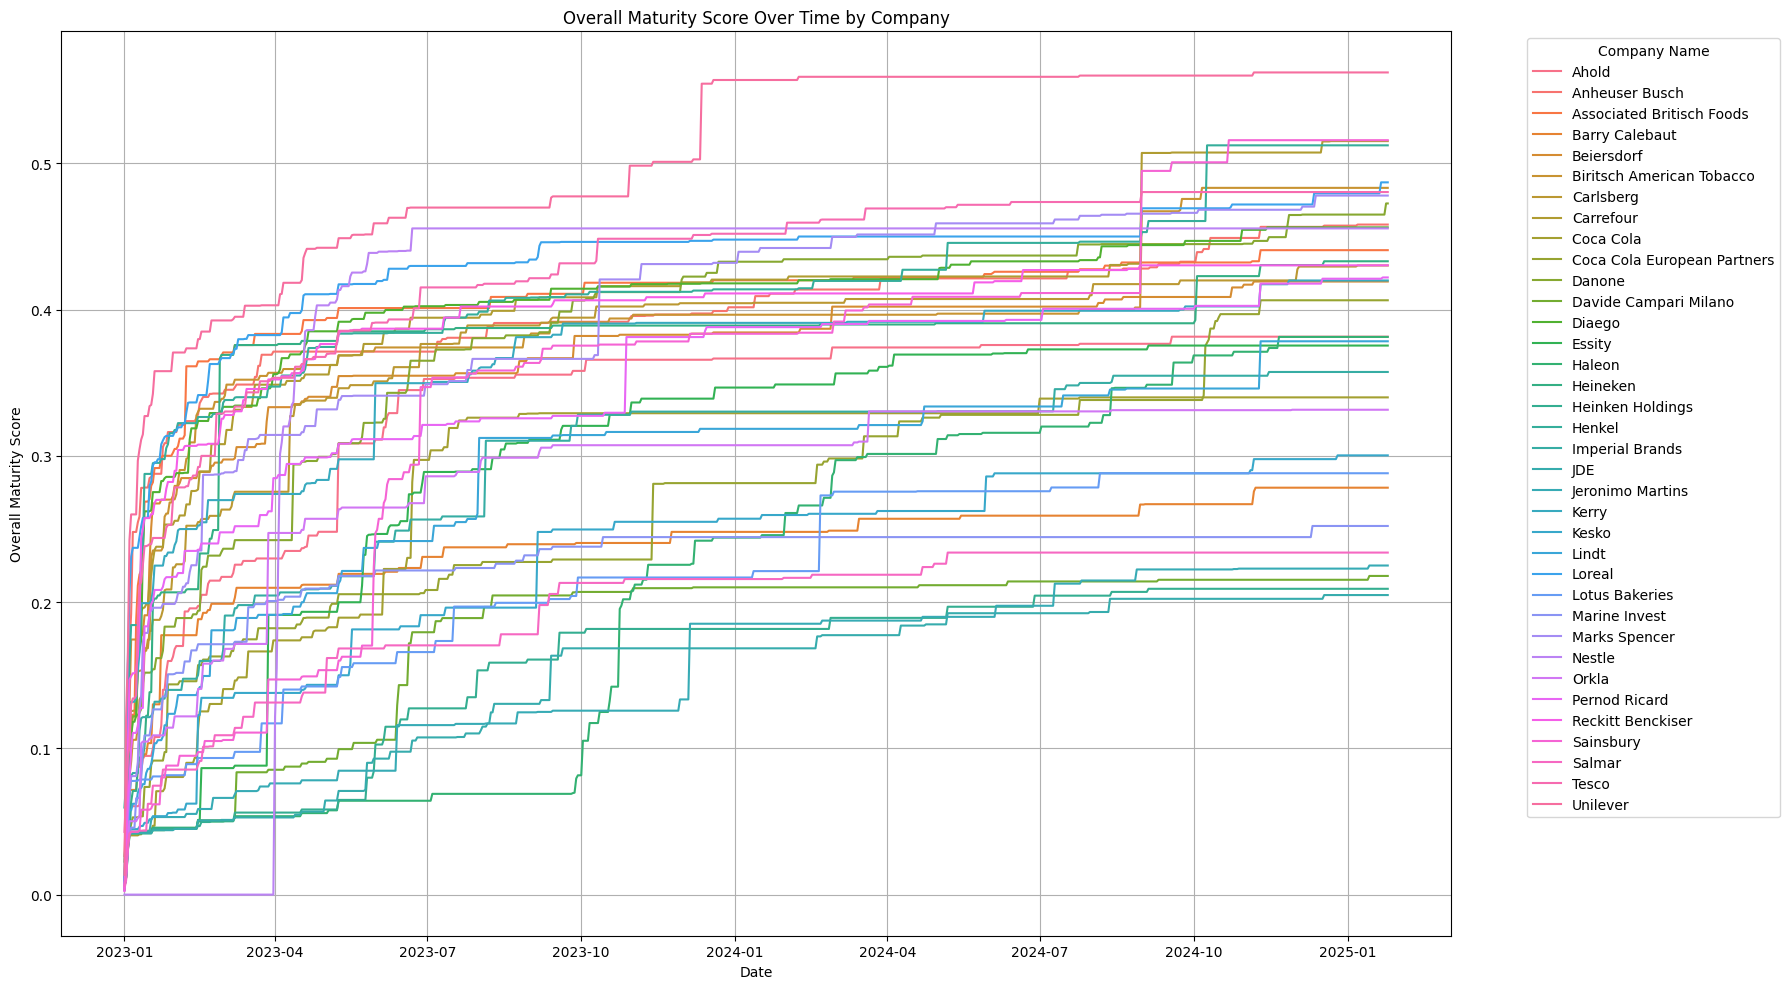

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sicherstellen, dass 'date' wirklich vom Typ datetime ist
weighted_maturity_scores_daily['date'] = pd.to_datetime(weighted_maturity_scores_daily['date'])

plt.figure(figsize=(18, 10))
sns.lineplot(
    data=weighted_maturity_scores_daily,
    x='date',
    y='Overall Maturity Score',
    hue='Company Name Full'
)

plt.title('Overall Maturity Score Over Time by Company')
plt.xlabel('Date')
plt.ylabel('Overall Maturity Score')
plt.legend(title='Company Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### hier ennde neue Pro Tag

In [16]:
# Convert 'date' to datetime, handling errors
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Convert 'date' to a monthly period
df['month'] = df['date'].dt.to_period('M')

In [17]:
cumulative_volume_per_month = df.groupby(['practice', 'Company Name Full', 'month', 'Supersector', 'capability', 'pillar'])['volume_weighted'].sum().reset_index()

# Rename the 'volume' column to 'cumulative_volume_per_month' for clarity
cumulative_volume_per_month.rename(columns={'volume_weighted': 'cumulative_volume_per_month'}, inplace=True)

In [18]:
# Define the function to assign scores
def assign_score(volume, percentiles):
    if volume == 0:
        return 0
    for i in range(10, 0, -1):  # Start from the highest percentile
        if volume > percentiles.get(f'p{i*10}', np.inf):
            return i
    return 1  # If the volume is not greater than any percentile, return the lowest score

# Calculate percentiles for each group
def calculate_percentiles(group):
    percentiles = np.percentile(group['cumulative_volume_per_month'], [10 * i for i in range(1, 11)])
    return pd.Series(percentiles, index=[f'p{10 * i}' for i in range(1, 11)])

# Apply the function to calculate percentiles for each 'practice', 'Supersector', and 'month' combination
percentile_df = cumulative_volume_per_month.groupby(['practice', 'Supersector', 'month']).apply(calculate_percentiles).reset_index()

# Merge the percentiles back into the original DataFrame
merged_df = pd.merge(cumulative_volume_per_month, percentile_df, on=['practice', 'Supersector', 'month'])

# Assign scores using the percentiles
merged_df['score'] = merged_df.apply(lambda row: assign_score(row['cumulative_volume_per_month'], row.to_dict()), axis=1)

# Debugging: Print the percentiles and scores for a specific practice and supersector in a specific month
debug_df = merged_df[(merged_df['practice'] == 'example_practice') & (merged_df['Supersector'] == 'example_supersector') & (merged_df['month'] == 'example_month')]
print(debug_df[['practice', 'Supersector', 'month', 'cumulative_volume_per_month', 'score', 'p10', 'p20', 'p30', 'p40', 'p50', 'p60', 'p70', 'p80', 'p90', 'p100']])

print(merged_df[['practice', 'Supersector', 'month', 'cumulative_volume_per_month', 'score']])


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_67268/3988397357.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  percentile_df = cumulative_volume_per_month.groupby(['practice', 'Supersector', 'month']).apply(calculate_percentiles).reset_index()


Empty DataFrame
Columns: [practice, Supersector, month, cumulative_volume_per_month, score, p10, p20, p30, p40, p50, p60, p70, p80, p90, p100]
Index: []
                                practice     Supersector    month  \
0               BMI-CCF-Capability Focus  Consumer Goods  2023-01   
1               BMI-CCF-Capability Focus  Consumer Goods  2023-02   
2               BMI-CCF-Capability Focus  Consumer Goods  2023-03   
3               BMI-CCF-Capability Focus  Consumer Goods  2023-04   
4               BMI-CCF-Capability Focus  Consumer Goods  2023-05   
...                                  ...             ...      ...   
149395  TI-SDH-Data Storage Optimization  Consumer Goods  2024-09   
149396  TI-SDH-Data Storage Optimization  Consumer Goods  2024-10   
149397  TI-SDH-Data Storage Optimization  Consumer Goods  2024-11   
149398  TI-SDH-Data Storage Optimization  Consumer Goods  2024-12   
149399  TI-SDH-Data Storage Optimization  Consumer Goods  2025-01   

        cumulative

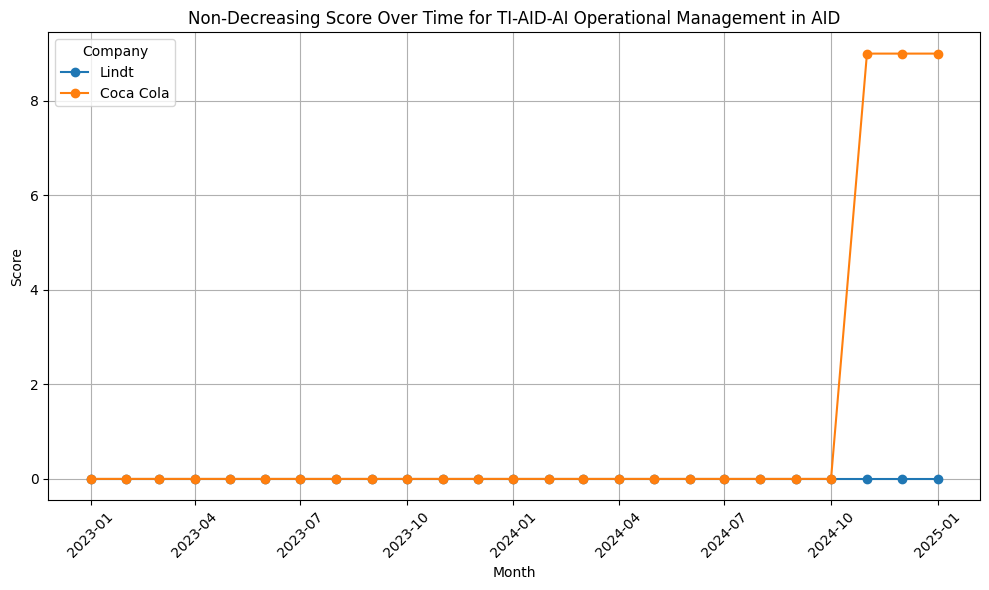

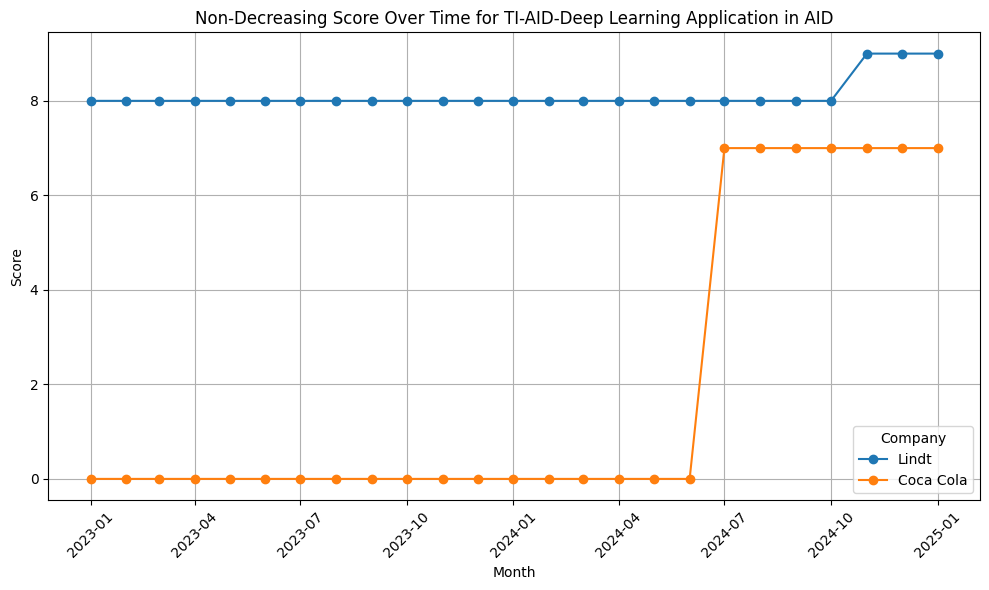

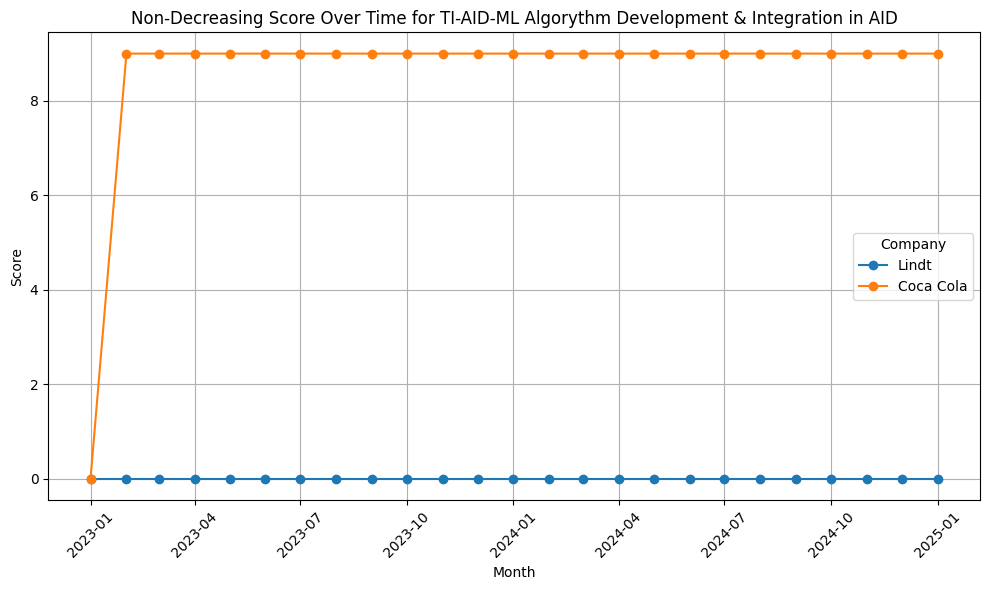

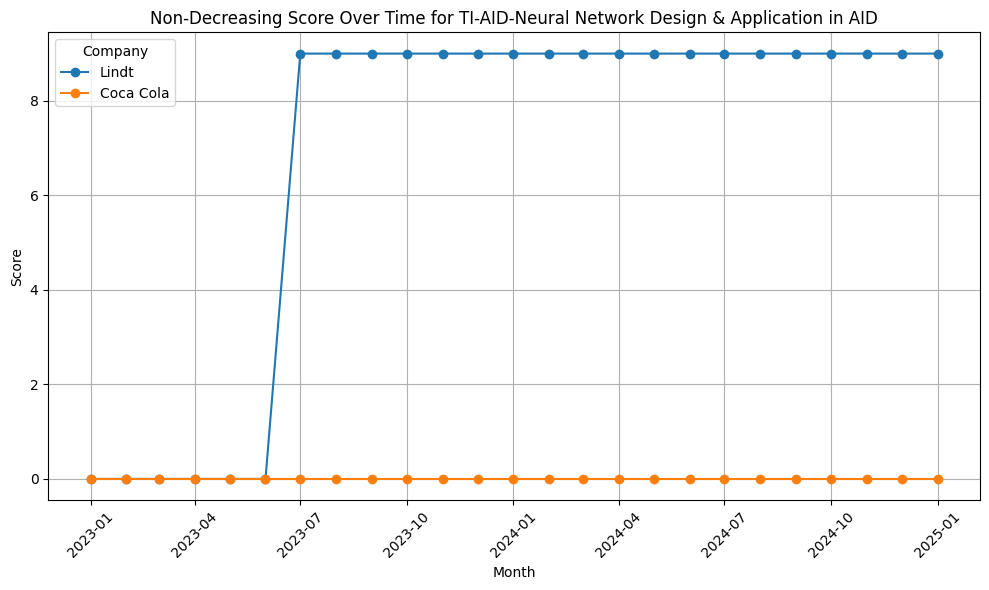

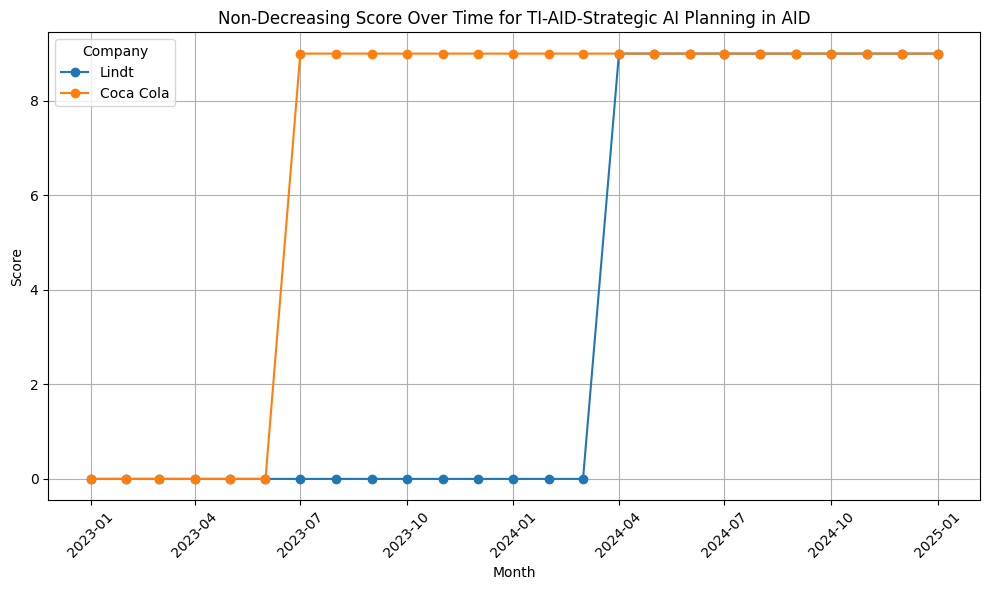

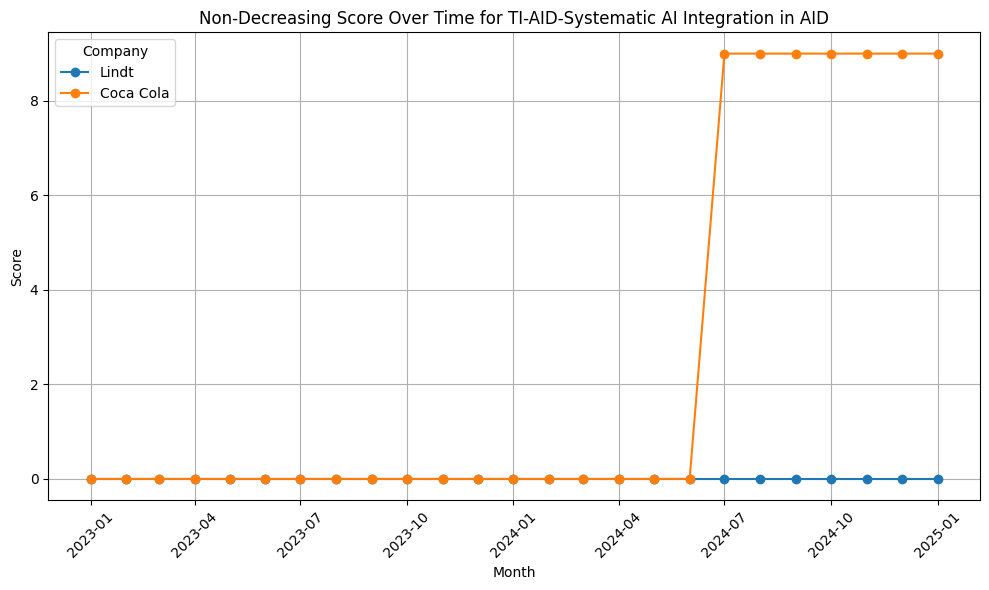

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data frame (assuming 'merged_df' is already loaded)
# merged_df = pd.read_csv('path_to_your_csv_file.csv')

def plot_non_decreasing_scores(df, company1, company2, capability):
    # Filter the DataFrame for the two companies and the specified capability
    filtered_df_BM = df[(df['Company Name Full'].isin([company1, company2])) & (df['capability'] == capability)]
    
    # Pivot the data for plotting with practices
    pivot_df_BM = filtered_df_BM.pivot_table(index=['month', 'practice'], columns='Company Name Full', values='score', aggfunc='mean').unstack('practice')
    
    # Get unique practices
    unique_practices = filtered_df_BM['practice'].unique()
    
    # Create a plot for each practice
    for practice in unique_practices:
        plt.figure(figsize=(10, 6))
        practice_data = pivot_df_BM.xs(practice, level='practice', axis=1)  # Data for the current practice
        
        # 🔥 Convert 'month' from PeriodIndex to DatetimeIndex for plotting
        practice_data.index = practice_data.index.to_timestamp()

        # Ensure scores do not decrease
        practice_data = practice_data.cummax()  # Apply cumulative max to each column

        # Plot lines for each company
        for company in [company1, company2]:
            if company in practice_data.columns:
                plt.plot(practice_data.index, practice_data[company], marker='o', label=f'{company}')
        
        plt.title(f'Non-Decreasing Score Over Time for {practice} in {capability}')
        plt.xlabel('Month')
        plt.ylabel('Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Rotate dates for better visibility
        plt.tight_layout()
        plt.show()

# Usage example
plot_non_decreasing_scores(merged_df, 'Lindt', 'Coca Cola', 'AID')

In [20]:
# Calculate the maximum possible score for each capability
max_scores_per_capability = merged_df.groupby('capability').agg({'practice': 'nunique'}).reset_index()
max_scores_per_capability['max_score_per_capability'] = max_scores_per_capability['practice'] * 10

# Sum the scores for each company, capability, supersector, pillar, and month
capability_scores = merged_df.groupby(['Company Name Full', 'capability', 'Supersector', 'pillar', 'month'])['score'].sum().reset_index()

# Rename the 'score' column to 'maturity_score' for clarity
capability_scores.rename(columns={'score': 'maturity_score'}, inplace=True)

# Merge the maximum scores for each capability back into the capability_scores DataFrame
final_scores = pd.merge(capability_scores, max_scores_per_capability[['capability', 'max_score_per_capability']], on='capability', how='left')

# Select relevant columns for display
final_scores = final_scores[['Company Name Full', 'capability', 'Supersector', 'pillar', 'month', 'maturity_score', 'max_score_per_capability']]

final_scores.head()




,Company Name Full,capability,Supersector,pillar,month,maturity_score,max_score_per_capability
0,Ahold,AID,Consumer Goods,TI,2023-01,0,60
1,Ahold,AID,Consumer Goods,TI,2023-02,0,60
2,Ahold,AID,Consumer Goods,TI,2023-03,0,60
3,Ahold,AID,Consumer Goods,TI,2023-04,9,60
4,Ahold,AID,Consumer Goods,TI,2023-05,0,60


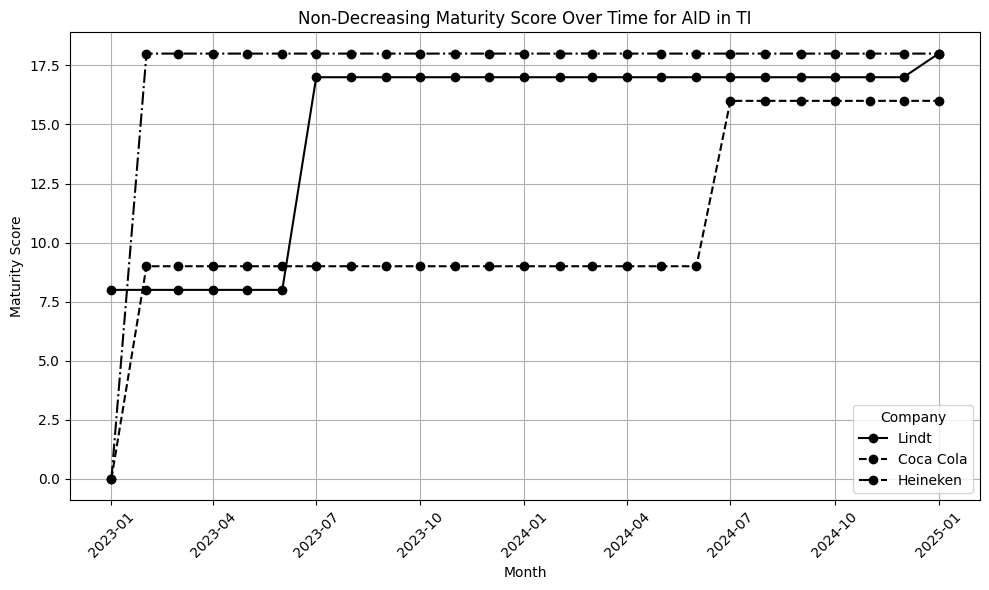

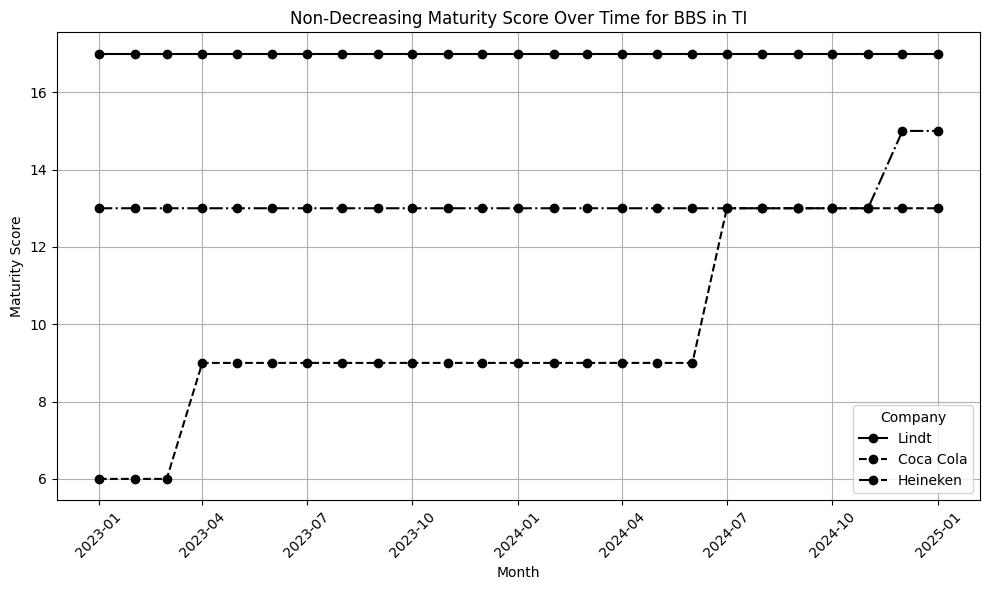

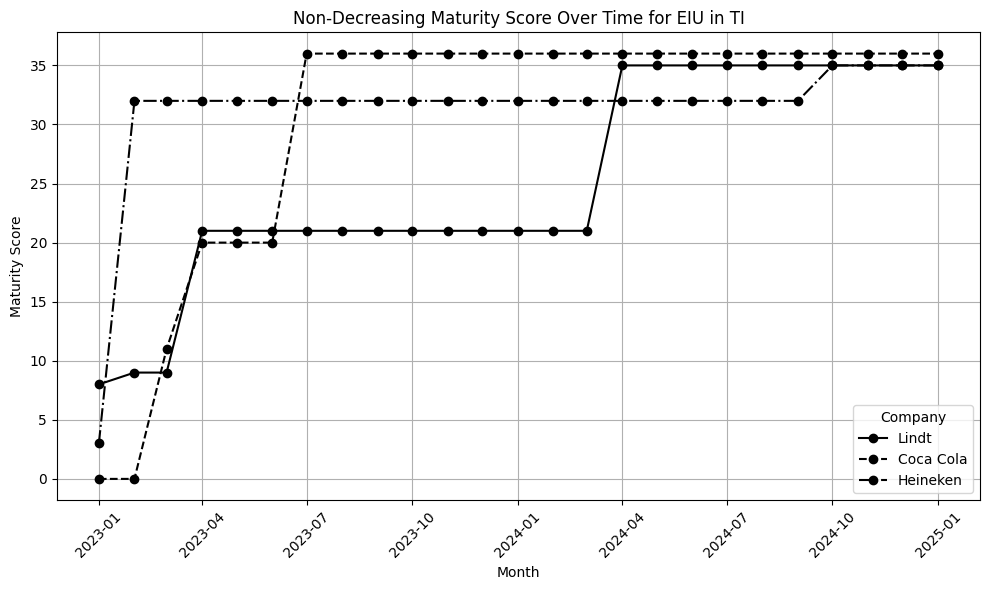

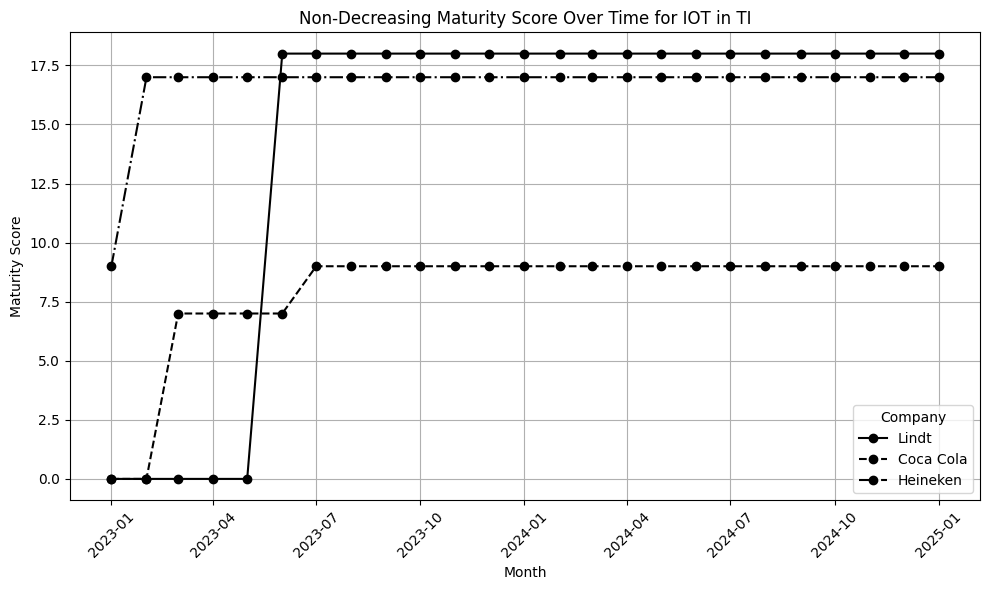

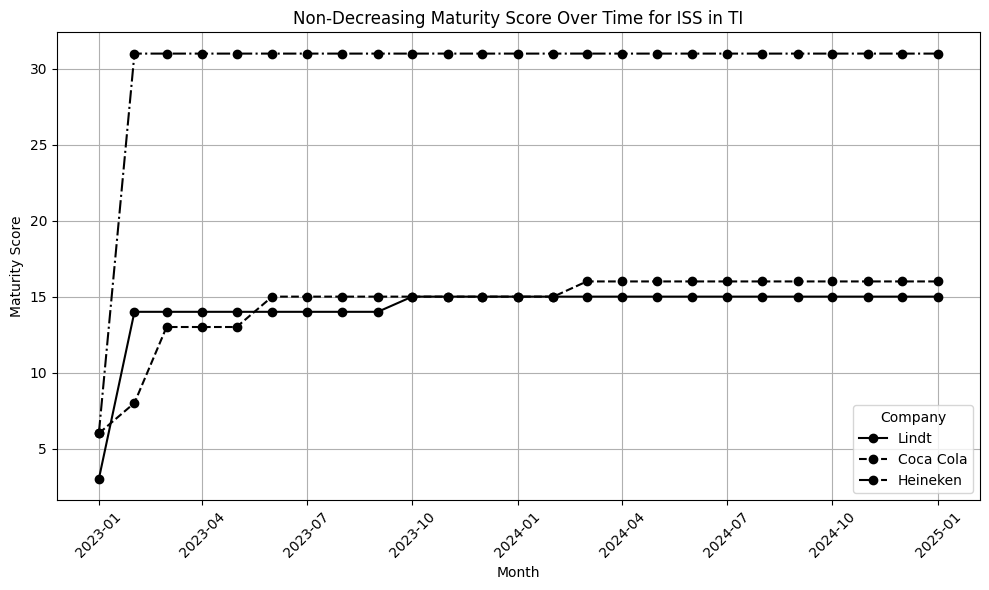

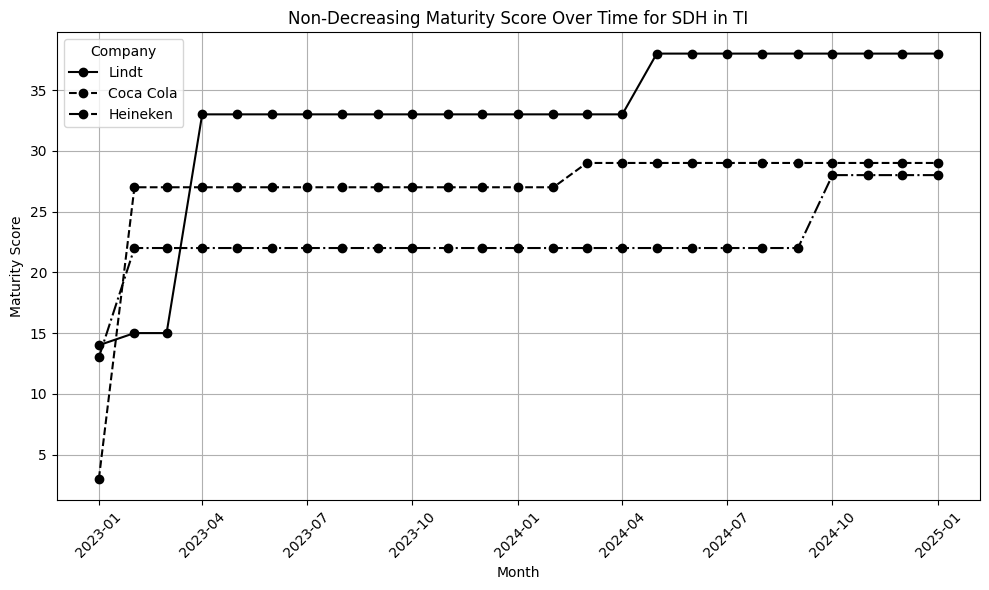

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_capability_scores(df, companies, pillar):
    # Filter the DataFrame for the specified companies and pillar
    filtered_df_BM2 = df[(df['Company Name Full'].isin(companies)) & (df['pillar'] == pillar)]
    
    # Pivot the data for plotting with capabilities
    pivot_df_BM2 = filtered_df_BM2.pivot_table(index=['month', 'capability'], 
                                               columns='Company Name Full', 
                                               values='maturity_score', 
                                               aggfunc='mean').unstack('capability')

    # Reset index to make 'month' a column, then convert it to datetime
    pivot_df_BM2 = pivot_df_BM2.reset_index()
    pivot_df_BM2['month'] = pivot_df_BM2['month'].dt.to_timestamp()  # Convert from Period to Datetime
    pivot_df_BM2.set_index('month', inplace=True)  # Set back as index

    # Get unique capabilities
    unique_capabilities = filtered_df_BM2['capability'].unique()
    
    # Define line styles for the companies
    line_styles = ['-', '--', '-.', ':']
    
    # Ensure there are enough line styles for the number of companies
    line_styles = (line_styles * (len(companies) // len(line_styles) + 1))[:len(companies)]

    # Create a plot for each capability
    for capability in unique_capabilities:
        plt.figure(figsize=(10, 6))
        
        # Extract data for the current capability
        capability_data = pivot_df_BM2.xs(capability, level='capability', axis=1)  

        # Ensure scores do not decrease over time
        capability_data = capability_data.cummax()  

        # Plot lines for each company with different line styles
        for idx, company in enumerate(companies):
            if company in capability_data.columns:
                plt.plot(capability_data.index,  # The index is now in datetime format
                         capability_data[company], 
                         marker='o', label=f'{company}', 
                         color='black', linestyle=line_styles[idx])
        
        plt.title(f'Non-Decreasing Maturity Score Over Time for {capability} in {pillar}')
        plt.xlabel('Month')
        plt.ylabel('Maturity Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Rotate dates for better visibility
        plt.tight_layout()
        plt.show()

# Usage example
plot_capability_scores(final_scores, ['Lindt', 'Coca Cola', 'Heineken'], 'TI')

In [22]:
# Step 1: Sort the DataFrame by company, capability, and month
final_scores_sorted = final_scores.sort_values(by=['Company Name Full', 'capability', 'month'])

# Step 2: Apply a cumulative maximum function to the maturity_score for each capability within each company
final_scores_sorted['adjusted_maturity_score'] = final_scores_sorted.groupby(['Company Name Full', 'capability'])['maturity_score'].cummax()

# Keep Supersector information
final_scores_with_supersector = final_scores_sorted[['Company Name Full', 'pillar', 'Supersector', 'month', 'adjusted_maturity_score', 'max_score_per_capability']]

# Now proceed with the pillar score calculation using the adjusted maturity score
# Sum the adjusted maturity scores and the maximum possible scores for each pillar
pillar_scores = final_scores_with_supersector.groupby(['Company Name Full', 'pillar', 'Supersector', 'month']).agg({
    'adjusted_maturity_score': 'sum', 
    'max_score_per_capability': 'sum'
}).reset_index()

# Calculate the pillar score as the ratio of the total adjusted maturity score to the total maximum score
pillar_scores['pillar_score'] = pillar_scores['adjusted_maturity_score'] / pillar_scores['max_score_per_capability']

# Select relevant columns for display
final_pillar_scores = pillar_scores[['Company Name Full', 'pillar', 'Supersector', 'month', 'pillar_score']]

print(final_pillar_scores)


     Company Name Full pillar     Supersector    month  pillar_score
0                Ahold    BMI  Consumer Goods  2023-01      0.200000
1                Ahold    BMI  Consumer Goods  2023-02      0.366667
2                Ahold    BMI  Consumer Goods  2023-03      0.376190
3                Ahold    BMI  Consumer Goods  2023-04      0.376190
4                Ahold    BMI  Consumer Goods  2023-05      0.376190
...                ...    ...             ...      ...           ...
8095          Unilever     TI  Consumer Goods  2024-09      0.622857
8096          Unilever     TI  Consumer Goods  2024-10      0.622857
8097          Unilever     TI  Consumer Goods  2024-11      0.622857
8098          Unilever     TI  Consumer Goods  2024-12      0.622857
8099          Unilever     TI  Consumer Goods  2025-01      0.622857

[8100 rows x 5 columns]


In [ ]:
import pandas as pd

# Define weights for each pillar (adjust these as needed)
pillar_weights = {
    'BMI': 0.4,  # Example: Business Model Innovation has full weight
    'CE': 1.68,   # Example: Customer Experience weighted at 90%
    #'CSE': 0.64,  # Example: Cybersecurity & Data Protection
    'CSG': 0.64,  # Example: Compliance & Sustainability
    'DA': 1.28,   # Example: Data Analytics gets higher weight
    'DLC': 1.68,  # Example: Digital Leadership Culture
    'DST': 0.64,  # Example: Digital Strategy & Transformation
    'PAO': 0.88,  # Example: Process Automation & Optimization
    'TI': 0.8    # Example: Technology Infrastructure weighted highest
}

# Step 1: Calculate mean pillar score for each company, pillar, and month
monthly_pillar_mean_scores = final_pillar_scores.groupby(
    ['Company Name Full', 'pillar', 'month']
)['pillar_score'].mean().reset_index()

# Step 2: Pivot table so each row represents a company-month combination, with each column as a pillar
pivot_table_monthly = monthly_pillar_mean_scores.pivot_table(
    index=['Company Name Full', 'month'],
    columns='pillar',
    values='pillar_score'
).reset_index()

# Step 3: Fill missing values with 0 (assuming companies may not have scores for all pillars every month)
pivot_table_monthly_filled = pivot_table_monthly.fillna(0)

# Step 4: Apply weighting to each pillar score
for pillar, weight in pillar_weights.items():
    if pillar in pivot_table_monthly_filled.columns:
        pivot_table_monthly_filled[pillar] *= weight  # Multiply each pillar's score by its weight

# Step 5: Compute the weighted overall maturity score
total_weight = sum(pillar_weights.values())  # Get total sum of all weights
pivot_table_monthly_filled['Overall Maturity Score'] = pivot_table_monthly_filled.iloc[:, 2:].sum(axis=1) / total_weight

# Step 6: Keep the final DataFrame with company, month, and weighted overall maturity score
weighted_maturity_scores_monthly = pivot_table_monthly_filled[['Company Name Full', 'month', 'Overall Maturity Score']]

# Display the final DataFrame
print(weighted_maturity_scores_monthly)

pillar Company Name Full    month  Overall Maturity Score
0                  Ahold  2023-01                0.143792
1                  Ahold  2023-02                0.191871
2                  Ahold  2023-03                0.212179
3                  Ahold  2023-04                0.231296
4                  Ahold  2023-05                0.274221
..                   ...      ...                     ...
895             Unilever  2024-09                0.564929
896             Unilever  2024-10                0.566375
897             Unilever  2024-11                0.571245
898             Unilever  2024-12                0.571245
899             Unilever  2025-01                0.571245

[900 rows x 3 columns]


In [57]:
# Merge the dataframes on 'Company Name Full' and 'month'
final_df= final_pillar_scores.merge(weighted_maturity_scores_monthly, on=['Company Name Full', 'month'], how='left')

# Print the final DataFrame
print(final_df)


NameError: name 'weighted_maturity_scores_monthly' is not defined

### Seperate Pillar Export

In [56]:
# Erstellen einer Kopie des DataFrames mit nur den Einträgen, bei denen die Spalte 'Pillar' den Wert 'TI' hat
final_df_ti = final_df[final_df['Pillar'] == 'TI'].copy()

# Ausgabe des neuen DataFrames
final_df_ti.head()

NameError: name 'final_df' is not defined

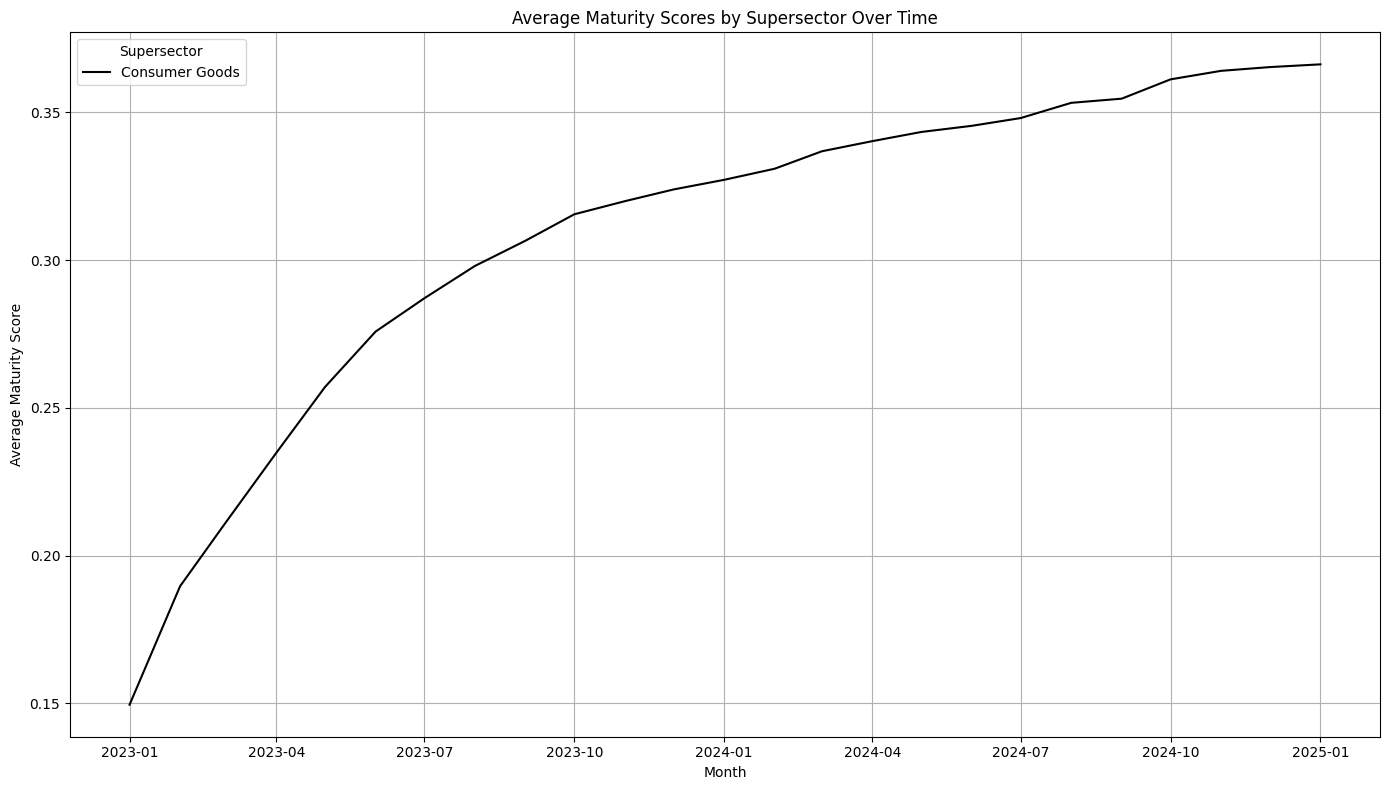

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming final_df is your DataFrame

# ✅ Convert 'month' from Period to Datetime
if isinstance(final_df['month'].dtype, pd.PeriodDtype):
    final_df['month'] = final_df['month'].dt.to_timestamp()

# Calculate the average maturity score for each supersector per month
average_maturity_scores = final_df.groupby(['month', 'Supersector'])['Overall Maturity Score'].mean().unstack()

# Calculate the final average maturity score for each supersector to determine the order in the legend
final_scores = average_maturity_scores.iloc[-1].sort_values(ascending=False)

# Define different line styles for the plot
line_styles = ['-', '--', '-.', ':', (0, (1, 1)), (0, (5, 5)), (0, (3, 5, 1, 5)), (0, (3, 10, 1, 10))]

# Plot the results
plt.figure(figsize=(14, 8))

for i, supersector in enumerate(final_scores.index):
    plt.plot(average_maturity_scores.index, average_maturity_scores[supersector], 
             label=supersector, linestyle=line_styles[i % len(line_styles)], color='black')

plt.title('Average Maturity Scores by Supersector Over Time')
plt.xlabel('Month')
plt.ylabel('Average Maturity Score')
plt.legend(title='Supersector')
plt.grid(True)
plt.tight_layout()
plt.show()

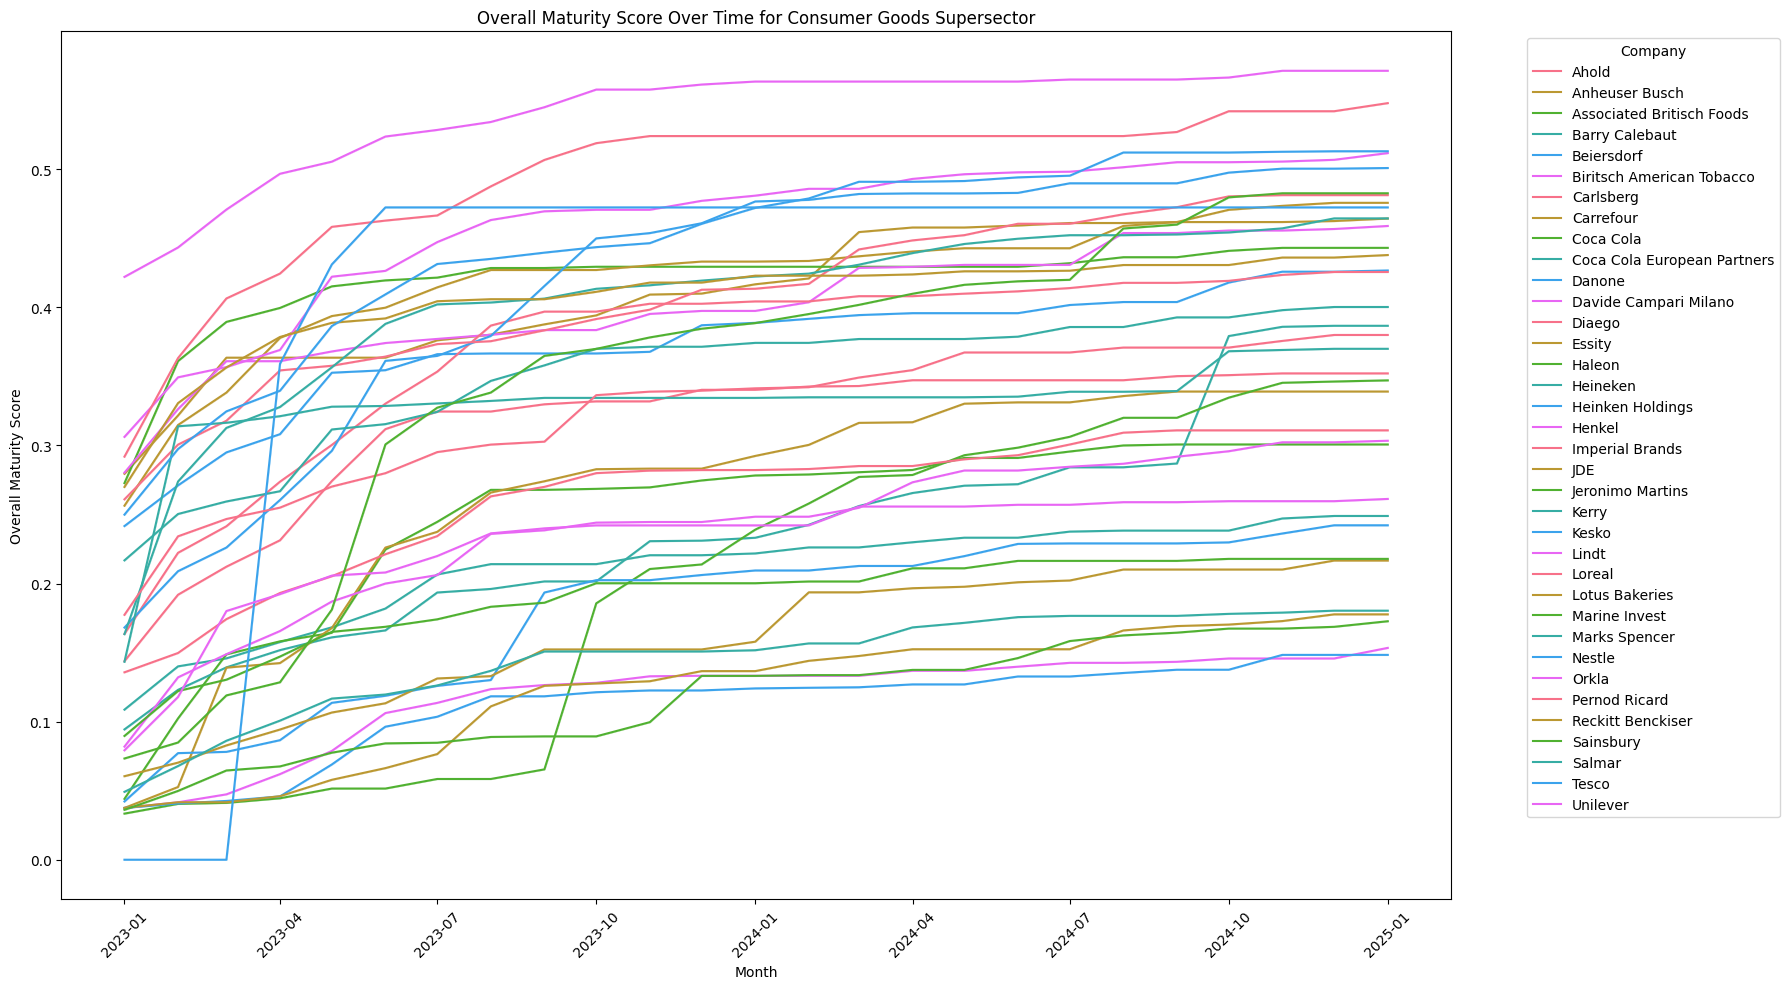

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming final_df is your DataFrame

# Ensure 'month' is in proper datetime format
if isinstance(final_df['month'].dtype, pd.PeriodDtype):
    final_df['month'] = final_df['month'].dt.to_timestamp()

# Filter the DataFrame for a specific supersector (e.g., 'Consumer Goods')
supersector = 'Consumer Goods'
filtered_df = final_df[final_df['Supersector'] == supersector]

# Get unique company names in the filtered DataFrame
companies = filtered_df['Company Name Full'].unique()

# Create a plot for each company
plt.figure(figsize=(18, 10))
sns.set_palette("husl")  # Use different colors for each company

for company in companies:
    company_data = filtered_df[filtered_df['Company Name Full'] == company]

    # ✅ Ensure 'month' is converted properly
    company_data = company_data.copy()  # Avoid SettingWithCopyWarning
    company_data['month'] = pd.to_datetime(company_data['month'])  # Convert correctly

    # Plotting overall maturity score per month for the company
    sns.lineplot(data=company_data, x='month', y='Overall Maturity Score', label=company)

# Adding labels and title
plt.title(f'Overall Maturity Score Over Time for {supersector} Supersector')
plt.xlabel('Month')
plt.ylabel('Overall Maturity Score')
plt.xticks(rotation=45)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()